# Training & Evaluation — Face Occlusion Model

In [16]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Find project root: parent of the notebooks/ directory
# __vsc_ipynb_file__ is set by VS Code to the notebook's absolute path
if "__vsc_ipynb_file__" in dir():
    PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))
else:
    # Fallback: assume cwd is either project root or notebooks/
    PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
print(f"Working directory: {os.getcwd()}")

%matplotlib inline

Working directory: /home/leo/Data_Challenge_Telecom/Data-Challenge-Telecom-Paris-Face-Occlusion


## 1. Load or Run Training

**Option A** : Entraîner depuis ce notebook (GPU requis) → exécuter la cellule suivante.

**Option B** : Charger l'historique depuis le cluster → sauter la cellule suivante, exécuter celle d'après.

In [17]:
# Option A : entraîner depuis le notebook (GPU requis)
# Décommenter pour lancer l'entraînement localement au lieu du cluster

# from src.train import train
#
# best_score, history = train(
#     backbone_name="convnext_tiny.fb_in22k_ft_in1k",
#     batch_size=32,
#     num_epochs=20,
#     freeze_epochs=2,
#     lr_head=1e-4,
#     lr_backbone=1e-5,
#     patience=5,
#     seed=42,
# )
# print(f"Best validation score: {best_score:.6f}")

In [18]:
# Option B : charger l'historique depuis le cluster
# (après avoir récupéré checkpoints/ via scp)
import json

CHECKPOINT_DIR = "data/submissions/checkpoints"
history_path = os.path.join(CHECKPOINT_DIR, "history.json")

with open(history_path) as f:
    history = json.load(f)

print(f"Loaded history: {len(history['epoch'])} epochs")
print(f"Best val_score: {min(history['val_score']):.6f}")

Loaded history: 20 epochs
Best val_score: 0.001251


## 2. Training Curves

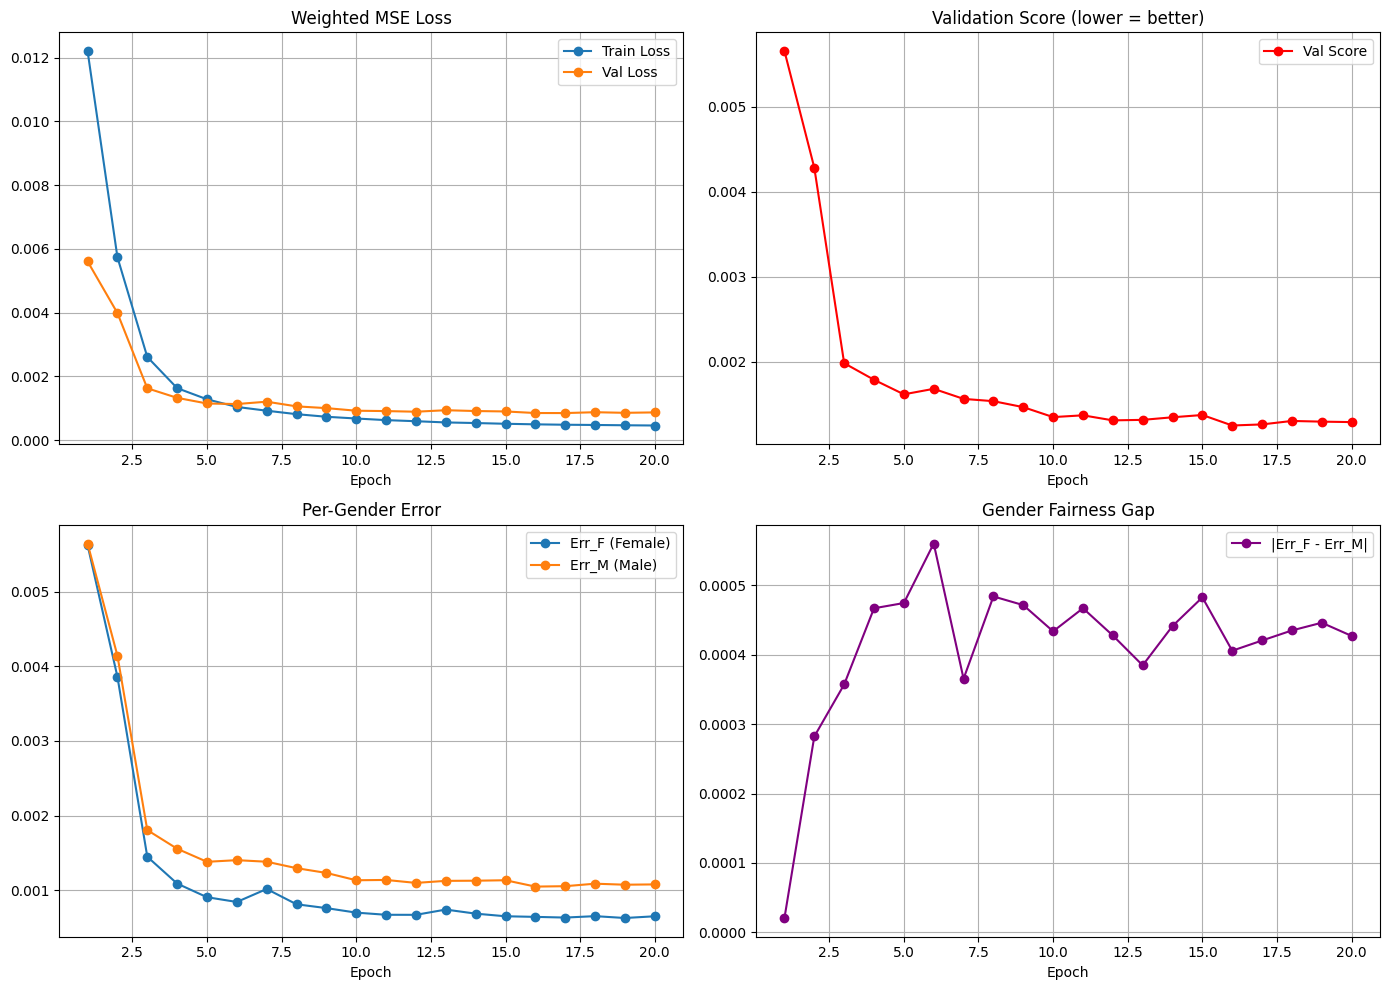

In [19]:
epochs = history["epoch"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(epochs, history["train_loss"], "o-", label="Train Loss")
axes[0, 0].plot(epochs, history["val_loss"], "o-", label="Val Loss")
axes[0, 0].set_title("Weighted MSE Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()
axes[0, 0].grid(True)

# Score
axes[0, 1].plot(epochs, history["val_score"], "o-", color="red", label="Val Score")
axes[0, 1].set_title("Validation Score (lower = better)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()
axes[0, 1].grid(True)

# Err_F vs Err_M
axes[1, 0].plot(epochs, history["err_f"], "o-", label="Err_F (Female)")
axes[1, 0].plot(epochs, history["err_m"], "o-", label="Err_M (Male)")
axes[1, 0].set_title("Per-Gender Error")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()
axes[1, 0].grid(True)

# Gender gap
gap = [abs(f - m) for f, m in zip(history["err_f"], history["err_m"])]
axes[1, 1].plot(epochs, gap, "o-", color="purple", label="|Err_F - Err_M|")
axes[1, 1].set_title("Gender Fairness Gap")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## 3. Validation Predictions Analysis

In [ ]:
import torch
from tqdm import tqdm
from src.model import FaceOcclusionModel
from src.dataset import get_dataloaders, _image_dir, DEFAULT_DATA_ROOT
from src.utils import set_seed, compute_score

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load best model
ckpt = torch.load("data/submissions/checkpoints/best_model.pt", map_location=device, weights_only=False)
model = FaceOcclusionModel(
    backbone_name=ckpt.get("backbone_name", "convnext_tiny.fb_in22k_ft_in1k"),
    pretrained=False,
)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device).eval()

_, val_loader, _, _ = get_dataloaders(batch_size=64, seed=42)

all_preds, all_targets, all_genders, all_filenames = [], [], [], []
with torch.no_grad():
    for imgs, targets, genders in tqdm(val_loader, desc="Val inference"):
        preds = model(imgs.to(device)).cpu()
        all_preds.append(preds)
        all_targets.append(targets)
        all_genders.append(genders)

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()
all_genders = torch.cat(all_genders).numpy()

score, err_f, err_m = compute_score(all_preds, all_targets, all_genders)
print(f"Val Score: {score:.6f}  |  Err_F: {err_f:.6f}  |  Err_M: {err_m:.6f}")

/home/leo/Data_Challenge_Telecom/Data-Challenge-Telecom-Paris-Face-Occlusion/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Val inference:   0%|          | 0/235 [00:00<?, ?it/s]/home/leo/Data_Challenge_Telecom/Data-Challenge-Telecom-Paris-Face-Occlusion/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Val inference:   7%|▋         | 17/235 [01:25<18:43,  5.15s/it]

## 4. Predictions vs Ground Truth

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: pred vs GT
axes[0].scatter(all_targets, all_preds, alpha=0.1, s=2)
axes[0].plot([0, 1], [0, 1], "r--", label="Perfect")
axes[0].set_xlabel("Ground Truth")
axes[0].set_ylabel("Prediction")
axes[0].set_title("Predictions vs Ground Truth")
axes[0].legend()

# Histogram comparison
axes[1].hist(all_targets, bins=50, alpha=0.6, label="Ground Truth", edgecolor="black")
axes[1].hist(all_preds, bins=50, alpha=0.6, label="Predictions", edgecolor="black")
axes[1].set_title("Distribution: GT vs Predictions")
axes[1].set_xlabel("Occlusion")
axes[1].legend()

# Error distribution
errors = all_preds - all_targets
axes[2].hist(errors, bins=50, edgecolor="black", alpha=0.7)
axes[2].axvline(0, color="r", linestyle="--")
axes[2].set_title(f"Error Distribution (mean={errors.mean():.4f}, std={errors.std():.4f})")
axes[2].set_xlabel("Prediction - GT")

plt.tight_layout()
plt.show()

## 5. Sample Predictions Grid

In [ ]:
from src.dataset import load_dataframes, split_train_val, _image_dir, DEFAULT_DATA_ROOT

IMAGE_DIR = _image_dir(DEFAULT_DATA_ROOT)
df_full, _ = load_dataframes()
_, df_val = split_train_val(df_full, seed=42)
df_val = df_val.reset_index(drop=True)

# Add predictions
df_val["pred"] = all_preds
df_val["error"] = np.abs(all_preds - all_targets)

# Show 16 random samples
sample = df_val.sample(16, random_state=123)
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img = Image.open(os.path.join(IMAGE_DIR, row["filename"]))
    ax.imshow(img)
    gender_str = "M" if row["gender"] == 1.0 else "F"
    ax.set_title(
        f"GT={row['FaceOcclusion']:.3f} Pred={row['pred']:.3f}\n"
        f"Err={row['error']:.3f} ({gender_str})",
        fontsize=8,
        color="red" if row["error"] > 0.1 else "black",
    )
    ax.axis("off")
plt.suptitle("Sample Predictions (red title = error > 0.1)", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Worst Predictions (Highest Error)

In [ ]:
worst = df_val.nlargest(16, "error")

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax, (_, row) in zip(axes.flatten(), worst.iterrows()):
    img = Image.open(os.path.join(IMAGE_DIR, row["filename"]))
    ax.imshow(img)
    gender_str = "M" if row["gender"] == 1.0 else "F"
    ax.set_title(
        f"GT={row['FaceOcclusion']:.3f} Pred={row['pred']:.3f}\n"
        f"Err={row['error']:.3f} ({gender_str})",
        fontsize=8, color="red",
    )
    ax.axis("off")
plt.suptitle("Worst 16 Predictions (highest absolute error)", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Generate Submission

In [ ]:
from src.predict import predict

predict(
    checkpoint_path="data/submissions/checkpoints/best_model.pt",
    output_path="data/submissions/test_predictions.csv",
    use_tta=True,
    batch_size=64,
)

# Verify submission
sub = pd.read_csv("data/submissions/test_predictions.csv")
print(f"\nSubmission shape: {sub.shape}")
print(f"Prediction range: [{sub['FaceOcclusion'].min():.4f}, {sub['FaceOcclusion'].max():.4f}]")
print(sub.head())